# Part 1:  Problem Definition & Dataset Verification

# Task 1

In [1]:
import pandas as pd
df=pd.read_csv("../LAB 03/clean_churn.csv")
df.duplicated().sum()
df = df.drop_duplicates() # forgot to save drop_duplicated back in csv in prev labs 
df.to_csv("../LAB 03/clean_churn.csv", index=False)
print("shape of dataset :",df.shape)
print("data types of dataset :\n",df.dtypes)

shape of dataset : (7021, 20)
data types of dataset :
 gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


# Task 1 interpretation
The cleaned Telco Churn dataset contains 7,021 customer records and 20 columns. The dataset contains both numerical and categorical variables. The numerical variables include tenure, SeniorCitizen, MonthlyCharges, and TotalCharges, while variables such as Contract, InternetService, and PaymentMethod are categorical. The target variable is Churn, which represents whether a customer left the service.

# Task 2
In Lab 3, the Decision Tree achieved an accuracy of 79.43%, precision of 62.03%, recall of 57.53%, and F1-score of 59.69% on the test set. In Lab 4, the default Random Forest achieved an accuracy of 77.22%, while the tuned Random Forest achieved 79.86% accuracy, 65.61% precision, 50.27% recall, and 56.93% F1-score. These results will be used as benchmarks when comparing Logistic Regression and KNN in this lab.

# Part 2 : Feature Scaling & Preparation 

# Task 3

In [2]:
X=df.drop("Churn",axis=1)
y=df["Churn"]
y = y.map({"No": 0, "Yes": 1})
print(y.value_counts())
X = pd.get_dummies(X, drop_first=True)
print("X shape after encoding:", X.shape)
print("\nData types:")
print(X.dtypes)

Churn
0    5164
1    1857
Name: count, dtype: int64
X shape after encoding: (7021, 30)

Data types:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No int

# Task 3 interpretation
The dataset was divided into features (X) and the target variable (y). The Churn target was converted from categorical values into binary values, where 0 represents “No” churn and 1 represents “Yes” churn. The categorical input features were converted into numerical form using one-hot encoding so that they could be used by machine-learning algorithms. The increase in the number of columns after encoding is expected because categorical variables are represented using separate numerical indicator columns.

# Task 4
Feature scaling is important for KNN because KNN uses distance calculations, so features with larger numerical ranges could dominate the distance. Scaling is also helpful for Logistic Regression because it puts features on comparable scales and can improve numerical optimization. Decision Trees and Random Forests do not require scaling because they make decisions using feature-based split thresholds rather than distance calculations.

# Task 5


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

X_train: (5616, 30)
X_test: (1405, 30)
y_train: (5616,)
y_test: (1405,)
Scaled training data shape: (5616, 30)
Scaled test data shape: (1405, 30)


# Task 5 interpretation
The dataset was divided into 80% training data and 20% testing data using a fixed random state of 42. Stratified splitting was used to maintain a similar proportion of churn and non-churn customers in both sets. StandardScaler was fitted only on the training data and then used to transform both the training and testing data. This prevents data leakage because information from the test set is not used to learn the scaling parameters. The scaled data will be used for Logistic Regression and KNN, while the previously used Decision Tree and Random Forest models do not require feature scaling.

# Part 3: Logistic Regression 

# Task 6


In [4]:
from sklearn.linear_model import LogisticRegression 
lr_model=LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled,y_train)
y_pred_lr=lr_model.predict(X_test_scaled)
print("Logistic Regression predictions:", y_pred_lr[:10])

Logistic Regression predictions: [1 1 0 0 0 0 0 1 0 0]


# Task 6 interpretation
A Logistic Regression model was trained using the scaled training data. The trained model was then used to predict churn on the unseen test data. The predictions contain binary class labels, where 0 represents no churn and 1 represents churn. These predictions will be evaluated using accuracy, precision, recall, F1-score, and a confusion matrix later.

# Task 7

In [5]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)
accuracy=accuracy_score(y_test,y_pred_lr)
precision=precision_score(y_test,y_pred_lr)
recall=recall_score(y_test,y_pred_lr)
f1=f1_score(y_test,y_pred_lr)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

cm=confusion_matrix(y_test,y_pred_lr)
print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.80355871886121
Precision: 0.6621621621621622
Recall   : 0.5268817204301075
F1-score : 0.5868263473053892

Confusion Matrix:
[[933 100]
 [176 196]]


# Task 7 interpretation
The Logistic Regression model achieved an accuracy of 80.36%, meaning that it correctly classified most of the test customers. Its precision was 66.22%, indicating that about two-thirds of the customers predicted as churners actually churned. The recall was 52.69%, meaning that the model correctly detected approximately half of the customers who actually churned. The F1-score was 58.68%, reflecting the balance between precision and recall. The confusion matrix shows 933 true negatives, 100 false positives, 176 false negatives, and 196 true positives. In particular, the 176 false negatives show that the model missed a considerable number of customers who actually churned.

# Task 8

In [6]:
y_prob_lr = lr_model.predict_proba(X_test_scaled)
print("First 10 probability predictions:")
print(y_prob_lr[:10,1])

First 10 probability predictions:
[0.75891304 0.6147742  0.28394934 0.0486018  0.00902546 0.32980849
 0.15474878 0.79230857 0.01749746 0.01511708]


# Task 8 interpretation
The predict_proba() output provides the estimated probability of churn for each test customer. For example, the first customer has a churn probability of approximately 75.89%, while the third customer has a probability of approximately 28.39%. Using the default threshold of 0.5, the first customer would be classified as a churner, while the third would be classified as a non-churner. Therefore, probability predictions provide more information about the model's confidence than the binary predictions returned by predict().


# Part 4 :  KNN & Choosing K 

# Task 9

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
k_values=[1,3,5,7,9,11,15,21]
knn_results=[]
for k in k_values:
    knn_model=KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled,y_train)
    y_pred_knn=knn_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)
    knn_results.append([k,accuracy,f1])
print("K\tAccuracy\tF1-score")
for result in knn_results:
    print(f"{result[0]}\t{result[1]:.4f}\t\t{result[2]:.4f}")
    

K	Accuracy	F1-score
1	0.7189		0.4698
3	0.7367		0.4818
5	0.7523		0.5000
7	0.7715		0.5368
9	0.7744		0.5439
11	0.7737		0.5444
15	0.7843		0.5702
21	0.7794		0.5609


# Task 9 interpretation
KNN was trained and evaluated using K values of 1, 3, 5, 7, 9, 11, 15, and 21. Accuracy and F1-score were recorded for each value of K. Testing multiple K values is necessary because a very small K can make KNN sensitive to individual observations and noise, while a very large K can make predictions too generalized. 

# Task 10

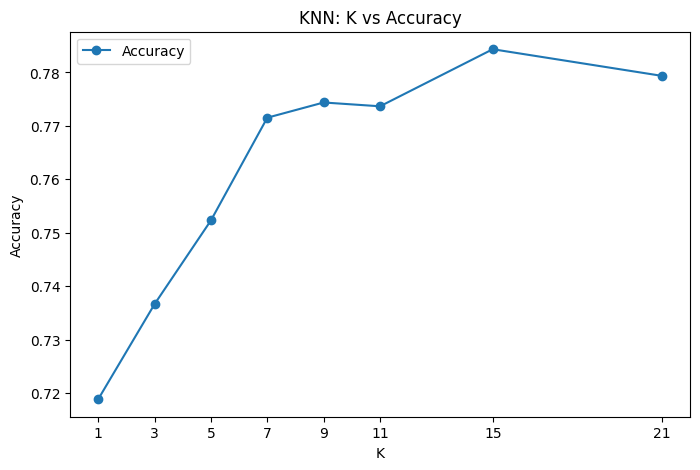

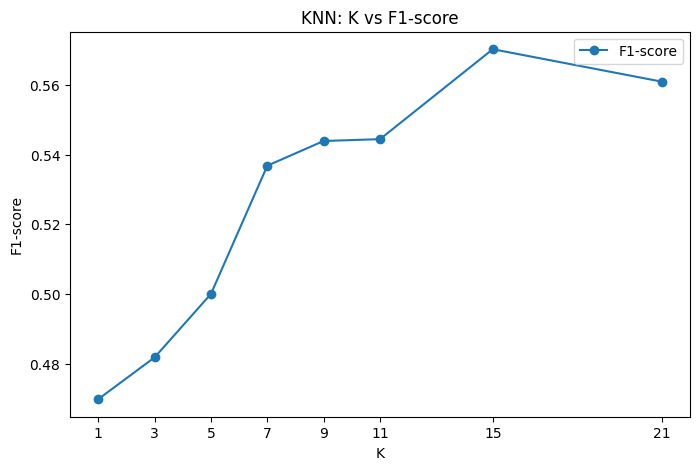

In [8]:
import matplotlib.pyplot as plt
k_values_plot=[result[0] for result in knn_results]
accuracy_values = [result[1] for result in knn_results]
f1_values = [result[2] for result in knn_results]
plt.figure(figsize=(8,5))
plt.plot(k_values_plot,accuracy_values,marker='o',label='Accuracy')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN: K vs Accuracy")
plt.xticks(k_values_plot)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values_plot, f1_values, marker='o', label='F1-score')
plt.xlabel("K")
plt.ylabel("F1-score")
plt.title("KNN: K vs F1-score")
plt.xticks(k_values_plot)
plt.legend()
plt.show()

# Task 10 interpretation
Both the graphs clearly show us that accuracy and f1-score both are maximum when k is equal to 15 

# Task 11

KNN Results (K = 15)
Accuracy : 0.7843416370106762
Precision: 0.6036036036036037
Recall   : 0.5403225806451613
F1-score : 0.5702127659574469
Confusion Matrix:
[[901 132]
 [171 201]]


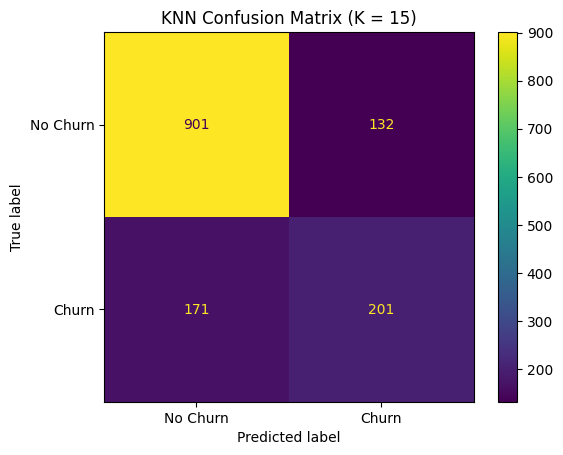

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,f1_score,recall_score,precision_score,confusion_matrix,ConfusionMatrixDisplay)
knn_final=KNeighborsClassifier(n_neighbors=15)
knn_final.fit(X_train_scaled,y_train)
y_pred_knn=knn_final.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)
print("KNN Results (K = 15)")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

cm=confusion_matrix(y_test,y_pred_knn)
print("Confusion Matrix:")
print(cm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Churn","Churn"])
disp.plot()
plt.title("KNN Confusion Matrix (K = 15)")
plt.show()

# Task 11 interpretation
Using the selected value of K = 15, the final KNN model achieved an accuracy of 78.43%, precision of 60.36%, recall of 54.03%, and F1-score of 57.02% on the test set. The confusion matrix shows that the model correctly classified 901 non-churning customers and 201 churning customers, while it incorrectly classified 132 non-churning customers as churners and missed 171 actual churners. The recall of 54.03% indicates that the model identified slightly more than half of the customers who actually churned. The F1-score of 57.02% reflects the balance between precision and recall and provides a more informative view of performance than accuracy alone for this imbalanced churn problem.

# Part 5 : Model Comparison

# Task 12

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        0.7943,
        0.7986,
        0.80355871886121,
        0.7843416370106762
    ],
    "Precision": [
        0.6203,
        0.6561,
        0.6621621621621622,
        0.6036036036036037
    ],
    "Recall": [
        0.5753,
        0.5027,
        0.5268817204301075,
        0.5403225806451613
    ],
    "F1-score": [
        0.5969,
        0.5693,
        0.5868263473053892,
        0.5702127659574469
    ]
})

comparison.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-score": "{:.2%}"
})

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,79.43%,62.03%,57.53%,59.69%
1,Random Forest,79.86%,65.61%,50.27%,56.93%
2,Logistic Regression,80.36%,66.22%,52.69%,58.68%
3,KNN,78.43%,60.36%,54.03%,57.02%


# Task 12 intepretation
The four models show different performance across the evaluation metrics. Logistic Regression achieved the highest accuracy (80.36%) and precision (66.22%), while the Decision Tree achieved the highest recall (57.53%) and F1-score (59.69%). The tuned Random Forest had 79.86% accuracy and the highest precision after Logistic Regression, but its recall was lower at 50.27%. KNN with K = 15 achieved 78.43% accuracy, with 60.36% precision, 54.03% recall, and 57.02% F1-score. Therefore, the model ranking changes depending on which metric is prioritized. Because the dataset has class imbalance and the goal is to identify customers who may churn, recall and F1-score are important alongside accuracy because accuracy alone may not show how well the model detects the minority churn class.

# Task 13
Because the Telco Churn dataset has class imbalance, accuracy alone should not be used to judge model performance. Recall is particularly important for this problem because it measures how many of the customers who actually churned are successfully identified, and a false negative represents a customer who churns but is not identified by the model. In our results, the Decision Tree achieved the highest recall of 57.53%, while Logistic Regression achieved the highest precision of 66.22% and accuracy of 80.36%. F1-score is also useful because it balances precision and recall, and the Decision Tree achieved the highest F1-score of 59.69%. Therefore, recall should receive significant attention when the main goal is to identify potential churners, while F1-score provides a useful overall measure when both missed churners and false alarms matter.

# Part 6:  Coefficient Interpretation

# Task 14

In [17]:
import numpy as np
coefficients = lr_model.coef_[0]

coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
})

coef_table

,Feature,Coefficient,Odds Ratio
0,SeniorCitizen,0.091838,1.096187
1,tenure,-1.410222,0.244089
2,MonthlyCharges,-0.535421,0.585423
3,TotalCharges,0.672041,1.958229
4,gender_Male,0.009035,1.009076
5,Partner_Yes,0.004593,1.004603
6,Dependents_Yes,-0.087961,0.915796
7,PhoneService_Yes,-0.050180,0.951058
8,MultipleLines_No phone service,0.050180,1.051461
9,MultipleLines_Yes,0.187062,1.205702


# Task 14 interpretation
The `tenure` feature has a coefficient of -1.410222 and an odds ratio of 0.244089. This negative coefficient indicates that higher tenure is associated with lower churn odds. Since the features were scaled before Logistic Regression, the coefficient represents a one-unit increase in the scaled tenure feature.

`TotalCharges` has a coefficient of 0.672041 and an odds ratio of 1.958229. This indicates that higher values of the scaled TotalCharges feature are associated with higher odds of churn, holding the other features constant.

`InternetService_Fiber optic` has a coefficient of 0.622899 and an odds ratio of 1.864325. This indicates that the fiber-optic category is associated with higher churn odds compared with the reference Internet Service category, while controlling for the other features.

`Contract_Two year` has a coefficient of -0.580891 and an odds ratio of 0.559400. This indicates that customers with a two-year contract have lower churn odds compared with the reference contract category, holding the other features constant.

Overall, the coefficients show that different features have different directions and strengths of association with churn. Features with positive coefficients are associated with higher churn odds, while features with negative coefficients are associated with lower churn odds.


# Task 15
The Logistic Regression findings were compared with the patterns observed during EDA in Lab 2 and the feature importances from the Decision Tree in Lab 3.
Contract type showed strong agreement across the analyses. In Lab 2, the churn rate was 42.71% for month-to-month customers, 11.27% for one-year customers, and 2.83% for two-year customers, showing a large difference across contract types. In Lab 3, `Contract_Month-to-month` had the highest Decision Tree feature importance of 0.522944. In Logistic Regression, `Contract_Two year` had a negative coefficient of -0.580891 and an odds ratio of 0.559400, indicating lower churn odds compared with the reference contract category.
Internet service type also showed consistent results. Lab 2 showed that fiber-optic customers had the highest churn rate at 41.89%. In Lab 3, `InternetService_Fiber optic` was the second most important feature with an importance of 0.168283. In Logistic Regression, it had a positive coefficient of 0.622899 and an odds ratio of 1.864325, indicating higher churn odds relative to the reference category.
Tenure also showed agreement across the three analyses. Lab 2 showed that churned customers had a lower mean and median tenure than non-churned customers. In Lab 3, `tenure` had a feature importance of 0.141143, making it one of the most important features. In Logistic Regression, `tenure` had a negative coefficient of -1.410222 and an odds ratio of 0.244089, indicating that higher tenure is associated with lower churn odds.
MonthlyCharges showed a different pattern. Lab 2 found that churned customers generally had higher monthly charges, while the Decision Tree assigned MonthlyCharges a relatively low feature importance of 0.018155. Logistic Regression produced a negative coefficient of -0.535421 and an odds ratio of 0.585423. This difference does not necessarily mean that the analyses are contradictory because EDA examines the feature relationship more directly, whereas Logistic Regression estimates the association while considering the other features in the model simultaneously.
Overall, Contract, Internet Service, and tenure showed consistent patterns across EDA, Decision Tree, and Logistic Regression. This increases confidence that these features contain useful information for predicting customer churn. However, the results should be interpreted as associations identified by the data and models rather than as proof that these features directly cause churn.
